<a href="https://colab.research.google.com/github/ldaniel-hm/eml_tabular/blob/main/MonteCarloTodasLasVisitas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Monte Carlo con Políticas epsilon-soft**

_Esto es un ejemplo de uso de Gymnasium e informe sobre un experimento de aprendizaje por refuerzo_

````
Luis D. Hernández.
<ldaniel at um.es>
````

Este notebook describe un experimento de aprendizaje por refuerzo utilizando el algoritmo de Monte Carlo con políticas epsilon-soft. El propósito de este análisis es entrenar un agente en un entorno de gym con el juego "FrozenLake", un entorno estándar en el que el agente debe aprender a moverse a través de un mapa en busca de una meta, evitando caer en agujeros. A continuación, se presenta una descripción de las diferentes partes del código y el proceso utilizado en el experimento.

🎯 **Ojo, el código debe modificarse para ser un auténtico Monte Carlo. Supongo que sabrás darte cuenta.**

## **1. Preparación del Entorno**

La preparación consta de las siguientes partes:
- **Instalación de Dependencias**: Se instalan las librerías necesarias para utilizar el entorno `gymnasium` para la simulación, con el objetivo de crear un ambiente controlado para que el agente pueda interactuar.
- **Importación de Librerías**: Se importan las bibliotecas necesarias como `numpy` para el manejo de matrices y `matplotlib` para la visualización de los resultados.

- **Importación del Entorno "FrozenLake"**:
Se cargan dos versiones del entorno "FrozenLake": una de 4x4 y otra de 8x8. Ambas versiones no son resbaladizas, lo que facilita la comprensión de los resultados, dado que el entorno resbaladizo podría dificultar la comprensión inicial del aprendizaje.

#### 3. **Funciones para Mostrar los Resultados**
   - Se define una función para graficar la proporción de recompensas obtenidas en cada episodio del entrenamiento. Esto ayuda a visualizar el progreso del agente en términos de su desempeño durante el entrenamiento.



##### _________ **Código de la Instalación e Importación**
----

In [80]:
%%capture
#@title Instalamos gym
#!pip install 'gym[box2d]==0.20.0'

## Instalación de algunos paquetes.
#!apt-get update
## Para usar gymnasium[box2d]
#!apt install swig
#!pip install gymnasium[box2d]

In [81]:
#@title Importamos librerias
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym

In [82]:
#@title Reproducibilidad
seed = 100

# Fijar la semilla en NumPy
np.random.seed(seed)
np.random.default_rng(seed)

Generator(PCG64) at 0x217D7697CA0

In [83]:
#@title Importamos el lago helado
name = 'FrozenLake-v1'
env4 = gym.make(name, is_slippery=False, map_name="4x4", render_mode="ansi") # No resbaladizo para entender mejor los resultados.
env8 = gym.make(name, is_slippery=False, map_name="8x8", render_mode="ansi") # No resbaladizo para entender mejor los resultados.

## **2. Diseño del Agente**

El diseño del agente consta de dos partes, el algoritmo con el que aprende y las políticas (toma de decisiones) que realiza.

- **Políticas del Agente**
   - **Política epsilon-soft**: Se define una política donde todas las acciones tienen una probabilidad de ser elegida.
   - **Política epsilon-greedy**: basada en la política epsilon-soft. De esta forma el agente tiene una pequeña probabilidad de explorar (tomar una acción aleatoria) y una mayor probabilidad de explotar (tomar la acción que considera mejor). Esto permite equilibrar la exploración y la explotación.
   - **Política greedy**: Es la usada una vez que "ha aprendido".

- **Algoritmo de Iteración de Valor**
  - Se implementa el algoritmo de iteración de valor utilizando Monte Carlo.
  - Se usa una versión "on-policy" de Monte Carlo con políticas epsilon greedy sobre una política epsilon-soft.
  - Se basa en el criterio de todas las visitas.
  - Otro aspecto es que la actualización de los retornos no se realiza en el orden inverso a las visitas.

#### **Código de las políticas y algoritmo MC**
----------------

In [84]:
class Agent:
    def __init__(self, env: gym.Env, epsilon: float = 0.4, decay: bool = False, discount_factor: float = 1.0):
        self.env = env
        self.nA = env.action_space.n
        self.nS = env.observation_space.n

        # Hiperparámetros
        self.epsilon = epsilon
        self.decay = decay
        self.discount_factor = discount_factor

        # Matriz de valores Q y contador de visitas
        self.Q = np.zeros([self.nS, self.nA])
        self.n_visits = np.zeros([self.nS, self.nA])

        # Buffer para almacenar la trayectoria del episodio actual
        self.episode = []

        # Variables para estadísticas y control de la evolución
        self.stats = 0.0
        self.list_stats = [self.stats]
        self.episodes_trained = 0

    def get_action_epsilon_greedy(self, state):
        """
        Política epsilon-greedy. Se usa para el entrenamiento.
        """
        # Inicializamos las probabilidades base para todas las acciones
        pi_A = np.ones(self.nA, dtype=float) * self.epsilon / self.nA
        
        # Buscamos la mejor acción actual
        best_action = np.argmax(self.Q[state])
        
        # Le sumamos a la mejor acción la probabilidad restante
        pi_A[best_action] += (1.0 - self.epsilon)
        
        # Elegimos la acción basándonos en la distribución de probabilidades
        return np.random.choice(np.arange(self.nA), p=pi_A)

    def get_action_greedy(self, state):
        """
        Política greedy. Se usa para mostrar la solución final.
        """
        return np.argmax(self.Q[state])

    def update(self, obs, action, next_obs, reward, terminated, truncated, info):
        """
        Con la muestra (s, a, s', r) e información complementaria aplicamos el algoritmo.
        Al ser Monte Carlo, acumulamos la experiencia y solo actualizamos al final del episodio.
        """
        # Guardamos el paso actual en nuestro buffer temporal
        self.episode.append((obs, action, reward))
        
        # Comprobamos si el episodio ha terminado
        if terminated or truncated:
            G = 0.0
            
            # Recorremos el episodio de atrás hacia adelante
            # Esto soluciona tu problema: ahora cada (estado, acción) recibe su propio G_t
            for state, act, rew in reversed(self.episode):
                G = rew + self.discount_factor * G
                
                self.n_visits[state, act] += 1.0
                alpha = 1.0 / self.n_visits[state, act]
                
                # Actualizamos Q (versión Every-visit on-policy)
                self.Q[state, act] += alpha * (G - self.Q[state, act])
                
            # Actualizamos las estadísticas para la gráfica de evolución
            # Al terminar el bucle, la variable G contiene el retorno total G_0
            self.stats += G
            self.episodes_trained += 1
            self.list_stats.append(self.stats / self.episodes_trained)
            
            # Aplicamos el decaimiento de epsilon (si está habilitado)
            if self.decay:
                self.epsilon = min(1.0, 1000.0 / (self.episodes_trained + 1))
                
            # Vaciamos el buffer de cara al siguiente episodio
            self.episode = []

In [85]:
# @title Políticas del agente

# actions
LEFT, DOWN, RIGHT, UP = 0,1,2,3

# Política epsilon-soft. Se usa para el entrenamiento
def random_epsilon_greedy_policy(Q, epsilon, state, nA):
    pi_A = np.ones(nA, dtype=float) * epsilon / nA
    best_action = np.argmax(Q[state])
    pi_A[best_action] += (1.0 - epsilon)
    return pi_A

# Política epsilon-greedy a partir de una epsilon-softq
def epsilon_greedy_policy(Q, epsilon, state, nA):
    pi_A = random_epsilon_greedy_policy(Q, epsilon, state, nA)
    return np.random.choice(np.arange(nA), p=pi_A)

# Política Greedy a partir de los valones Q. Se usa para mostrar la solución.
def pi_star_from_Q(env, Q):
    done = False
    pi_star = np.zeros([env.observation_space.n, env.action_space.n])
    state, info = env.reset() # start in top-left, = 0
    actions = ""
    while not done:
        action = np.argmax(Q[state, :])
        actions += f"{action}, "
        pi_star[state,action] = action
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
    return pi_star, actions

In [86]:
#@title Algoritmo de Iteración de Valor versión MC con Políticas epsilon-soft

def on_policy_all_visit(env, num_episodes=5000, epsilon=0.4, decay=False, discount_factor=1):
  # Matriz de valores  Q
  # Inicializamos Q
  # Donde metemos la recompensa que nos da cada acción 
  nA = env.action_space.n
  Q = np.zeros([env.observation_space.n, nA])

  # Número de visitas. Vamoa a realizar la versión incremental.
  n_visits = np.zeros([env.observation_space.n, env.action_space.n])

  # Para mostrar la evolución en el terminal y algún dato que mostrar
  stats = 0.0
  list_stats = [stats]
  step_display = num_episodes / 10

  episode_lengths = []

# En un rango de episodios DEFINIDO generamos un episodio 
  for t in tqdm(range(num_episodes)):
      # en cada episodio inicializamos las cosas que queremos obtener en cada episodio:
      # estado, acciones, recompensas (las cosas q se necesitan para calcular la ganancia total)

      #NOTA: A LA IA LE HA CHIRRIADO ESTA SEMILLA
      state, info = env.reset(seed=seed)
      done = False
      episode = []
      result_sum = 0.0  # Retorno
      factor = 1
      # empezamos en un estado inicial
      # mientras que los estados no sean terminales (o fin o mal)

      step_count = 0
      while not done:
          if decay:
            epsilon = min(1.0, 1000.0/(t+1))
        # elegimos según el estado en el que estemos una acción según la politica e-greedy 
          action = epsilon_greedy_policy(Q, epsilon, state, nA)
          # ejecutamos esa acción y obtenemos la recompensa y el siguiente estado
          new_state, reward, terminated, truncated, info = env.step(action)
          step_count += 1
          done = terminated or truncated

          # Obtenemos el retorno/ganancia de ese paso
          # CONCEPTO QUE ESTA MAL DE MONTECARLO; en Monte Carlo, cada decisión (cada par (estado, acción)) debe actualizarse con lo que pasó 
          # DESDE ESE MOMENTO hasta el final (el retorno Gt) 
          # EN el código, en cambio, le mete a todas las decisiones el mismo número (la recompensa total del episodio)

          # En montecarlo se calcula el retorno por cada tiempo/paso
          # con esta forma lo que estas haciendo es devolver todo a la vez por lo que da igual si la acción fue al principio al final --> todas valen lo mismo 
          # estas trabjando todo el rato sobre G0
          # Guardamos los resultados

          # montecarlo correcto --> cada state_t, action_t (siendo t isntante de tiempo) se actualiza con su propio Gt
          # AQUI deberiamos añadir el reward del episode.append((state, action, reward))
          episode.append((state, action, reward))
          state = new_state
      
      # Guardamos la longitud del episodio para mostrar la evolución.
      episode_lengths.append(step_count)

      # Esto es un disparate ¿por qué? --> PROQUE EN MONTERCARLO calculamos los retornos de cada episodio para atras
      # deberia ser algo asi: G = 0
    #for (state, action, reward) in reversed(episode):
    #G = reward + discount_factor * G
    #n_visits[state, action] += 1
    #alpha = 1.0 / n_visits[state, action]
    #Q[state, action] += alpha * (G - Q[state, action])
      
      # Actualizamos Q para ajustarnos a ese retorno

      G = 0.0
      for (state, action, reward) in reversed(episode):
          G = reward + discount_factor * G
          n_visits[state, action] += 1.0
          alpha = 1.0 / n_visits[state, action]
          # POR ESTO Q[state, action] es onpolicy estamos evaluando sobre nuestros propios episodioas
          # para que fuese off policy deberiamos cambiar el codigo para que calculase las probabilidades de cada acción segun lo que quieres aprender
          # y dos politicas --> la que quieres aprender y la que esta generando episodios (on-policy)
          Q[state, action] += alpha * (G - Q[state, action])

          # En este caso estamos implementado la versión Every-visit --> evaluamos la ganancia en cada instante del tiempo en el que
          # un estado es visitado (si fuese first-visit, seria solo la primera vez )


      # Ajudtamos la politica
      # Guardamos datos sobre la evolución. Promedio de recompensas
      stats += G
      list_stats.append(stats/(t+1))

      # Para mostrar la evolución.  Comentar si no se quiere mostrar
      if t % step_display == 0 and t != 0:
          print(f"success: {stats/t}, epsilon: {epsilon}")

  return Q, list_stats, episode_lengths


## **3. Experimentación**

   - En esta sección, el algoritmo de Monte Carlo con la política epsilon (decaimiento) se ejecuta tanto para el entorno de 4x4 como al de 8x8 de FrozenLake sin resbalar.
   
   - En ambos casos se realiza un entrenamiento con un número determinado de episodios (5000 en concreto)

   - Además en el escenario 8x8 el  epsilon tiene decaimiento de acuerdo a la expresión: $\epsilon = min(1.0, 1000.0/(t+1))$

   - Durante el entrenamiento hay una visualización de la proporción de recompensas obtenidas a lo largo del entrenamiento.

   - Junto a dicho volcado se muestra gráficamente la proporcion de recompensas obtendias.

   - También se hace un volcado de los valores Q de cada estado, donde se muestra cómo el agente valora diferentes acciones en distintos estados del entorno, lo que puede interpretarse como su conocimiento sobre las mejores estrategias para alcanzar la meta sin caer en los agujeros.

   - Además, se muestra la política óptima derivada de los valores Q. Esta política es la que el agente seguiría si tuviera que elegir siempre la acción que maximiza su recompensa esperada.

   

### **3.1 Repressentaciones Gráficas**

Para comprobar el aprendizaje se mostrará la función $f(t)=\frac{\sum_{i=1}^t R_i}{t}$ para $t=1,2,\ldots, NumeroEpisodios$. La justificación es la siguiente. Como sabemmos que el retorno en el estados inicial 1 (pues no hay descuento) o 9, si se divide por el número de episodios ejecutados se calcular el porcentaje de recompensas positivas obtenidas. Dicho de otra forma, nos dirá el porcentaje de veces que el agente ha llegado al estado terminal.

*TODO:* Contruir una gráfica que muestre la longitud de los episodios en cada estado junto con la curva de tendencia.

In [87]:
# @title Funciones para mostrar los resultados

def plot(list_stats):
  # Creamos una lista de índices para el eje x
  indices = list(range(len(list_stats)))

  # Creamos el gráfico
  plt.figure(figsize=(6, 3))
  plt.plot(indices, list_stats)

  # Añadimos título y etiquetas
  plt.title('Proporción de recompensas')
  plt.xlabel('Episodio')
  plt.ylabel('Proporción')

  # Mostramos el gráfico
  plt.grid(True)
  plt.show()

# Define la función para mostrar el tamaño de los episodios
# Pon aquí tu código.

# @title Mostrar longitud de los episodios


# cuantos pasos necesita el agente para terminar el episodio t
def plot_episode_length(episode_lengths):
    # Índices eje X
    indices = list(range(len(episode_lengths)))

    # Crear gráfico
    plt.figure(figsize=(30, 10))
    plt.plot(indices, episode_lengths)

    plt.title("Longitud de los episodios")
    plt.xlabel("Episodio")
    plt.ylabel("len(episodio)")
    plt.legend()
    plt.grid(True)
    plt.show()

### **3.2 Experimentación en el escenario 4x4**



   - Se realizan 5000 epsisodios y se actualizan los valores Q (valor de acción) basándose en las recompensas obtenidas durante cada episodio completo (e.d. aplicamos Monte Carlo) Se apica una política $\epsilon$ greedy sobre una política $\epsilon$ soft con un valor $\epsilon$ constante




In [88]:
# @title Aprendizaje
Q, list_stats, episode_lengths = on_policy_all_visit(env4, num_episodes=50000, epsilon=0.4, discount_factor=1)

 11%|█         | 5424/50000 [00:01<00:12, 3545.18it/s]

success: 0.4894, epsilon: 0.4


 21%|██        | 10616/50000 [00:03<00:10, 3818.07it/s]

success: 0.5056, epsilon: 0.4


 31%|███▏      | 15659/50000 [00:04<00:08, 3830.70it/s]

...

 81%|████████  | 40395/50000 [00:12<00:03, 3029.28it/s]

success: 0.5119, epsilon: 0.4


 91%|█████████ | 45537/50000 [00:14<00:01, 3098.67it/s]

success: 0.5144666666666666, epsilon: 0.4


100%|██████████| 50000/50000 [00:15<00:00, 3183.42it/s]


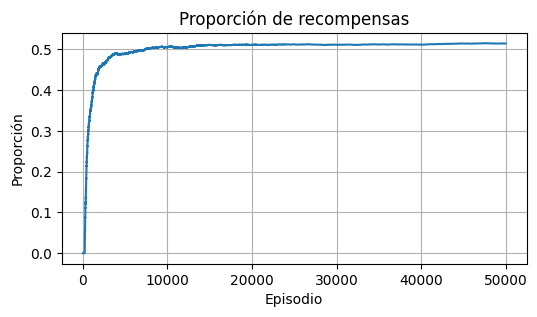

C:\Users\David\AppData\Local\Temp\ipykernel_50992\2428731217.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Máxima proporcion: 0.51462


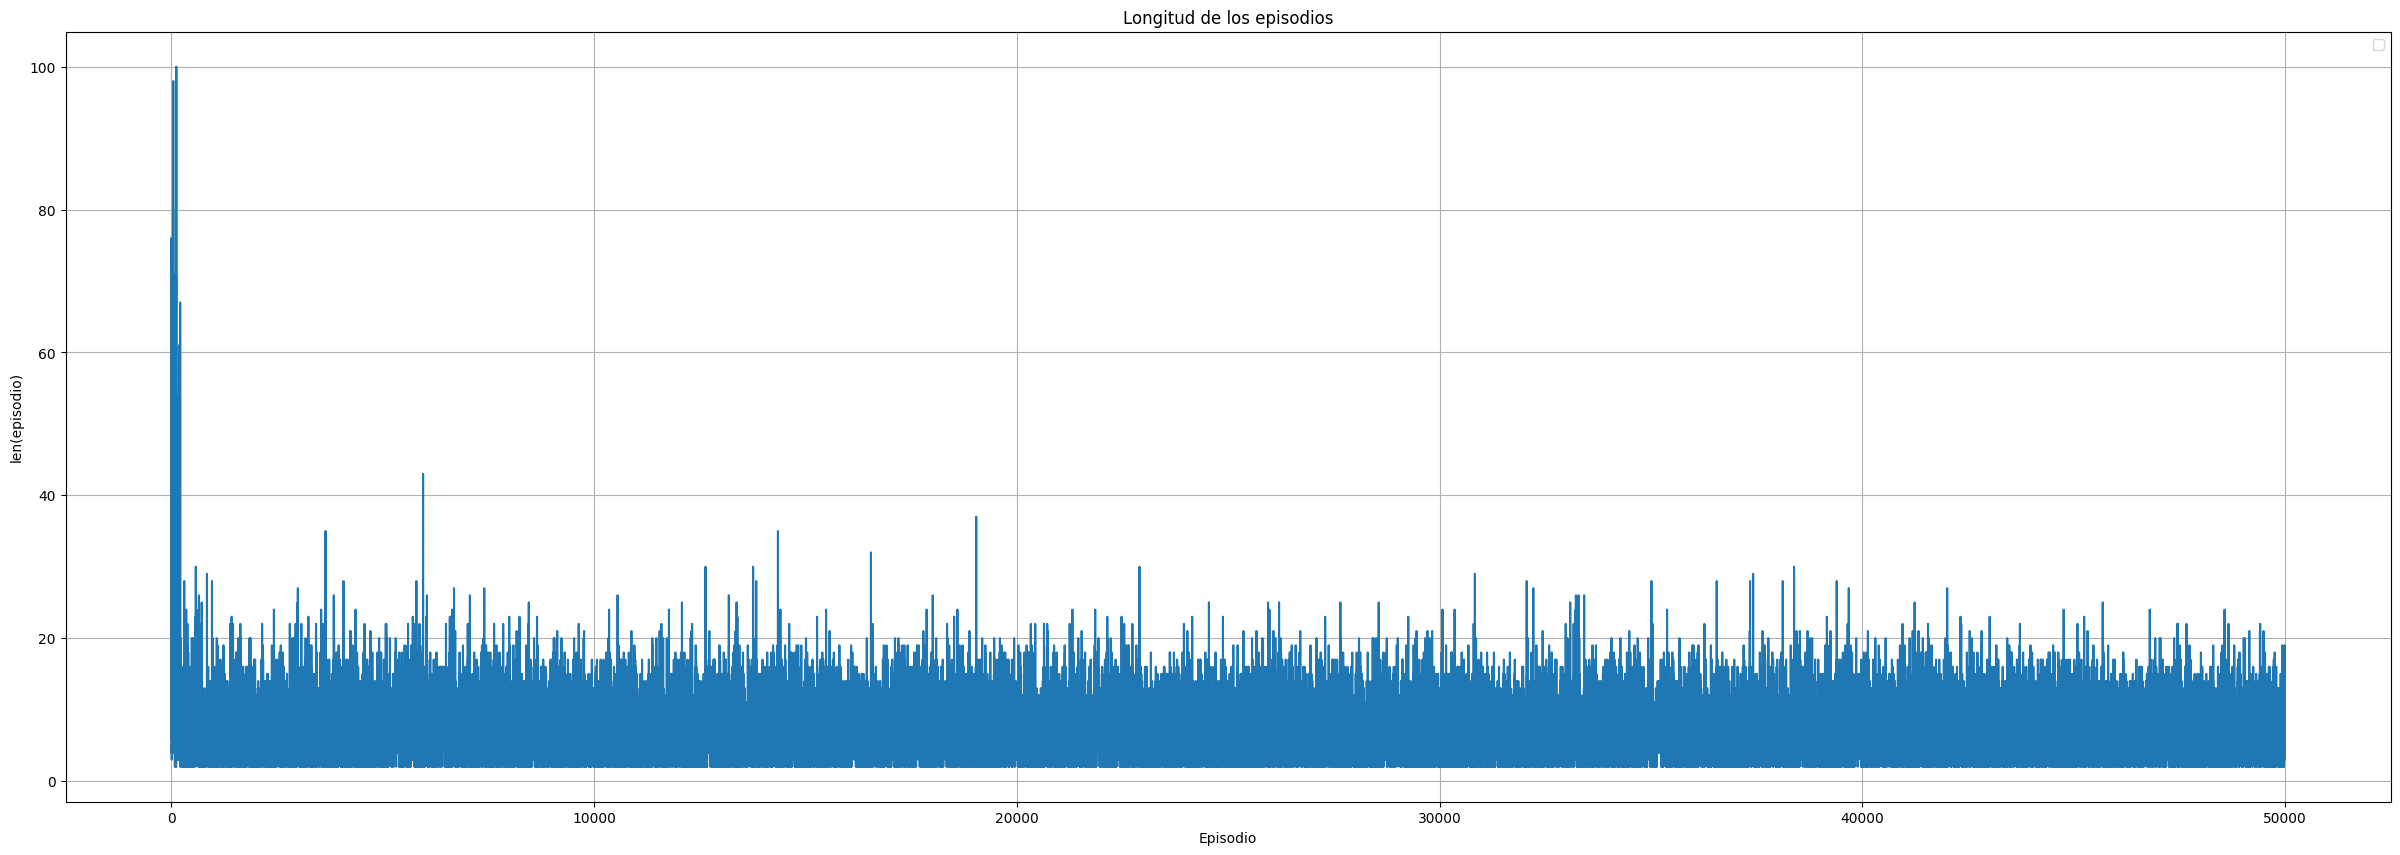

In [89]:
#@title Proporción de aciertos por número de episodios

plot(list_stats)
print(f"Máxima proporcion: {list_stats[-1]}")

plot_episode_length(episode_lengths)

#### Mostramos los valores Q para cada estado. Cada estado tienen 4 valores, que se corresponden con las 4 acciones que se pueden en cada estado.

In [90]:
# @title Tabla de valores Q
LEFT, DOWN, RIGHT, UP = 0,1,2,3
print("Valores Q para cada estado:\n", Q)


Valores Q para cada estado:
 [[0.39798865 0.44270384 0.52062199 0.50091053]
 [0.48903446 0.         0.59942363 0.52847682]
 [0.51816271 0.62262459 0.52380219 0.59360936]
 [0.6000706  0.         0.53421369 0.5309633 ]
 [0.22788204 0.47338936 0.         0.50387244]
 [0.         0.         0.         0.        ]
 [0.         0.80520376 0.         0.60445515]
 [0.         0.         0.         0.        ]
 [0.16932271 0.         0.70179641 0.38943894]
 [0.53299492 0.82359427 0.81052632 0.        ]
 [0.71519471 0.95828164 0.         0.63435039]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.80882353 0.95632468 0.71559633]
 [0.81162214 0.95803261 1.         0.8097166 ]
 [0.         0.         0.         0.        ]]


- También se muestra la política óptima (greedy) obtenida a partir del aprendizaje anterior.

- Cada estado tienen 4 valores, pero todos son 0 menos 1. Es decir, en cada estado se aplica de manera determinística una única acción.

*TODO:* Mostrar de forma gráfica el escenario.

In [91]:
# @title Política final
LEFT, DOWN, RIGHT, UP = 0,1,2,3
pi, actions = pi_star_from_Q(env4, Q)

print("Política óptima obtenida\n", pi, f"\n Acciones {actions} \n Para el siguiente grid\n", env4.render())
print()

Política óptima obtenida
 [[0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 0. 0.]] 
 Acciones 2, 2, 1, 1, 1, 2,  
 Para el siguiente grid
   (Right)
SFFF
FHFH
FFFH
HFFG




### **3.3 Experimentación en el escenario 8x8**

  - Se realizan 5000 epsisodios y se actualizan los valores Q (valor de acción) basándose en las recompensas obtenidas durante cada episodio completo (e.d. aplicamos Monte Carlo) Se apica una política $\epsilon$ greedy sobre una política $\epsilon$ soft con un valor $\epsilon$ decreciente



In [92]:
# @title Aprendizaje
Q, list_stats, episode_lengths = on_policy_all_visit(env8, num_episodes=50000, epsilon=0.4, decay=True, discount_factor=1)

 10%|█         | 5075/50000 [00:08<01:16, 583.89it/s]

success: 0.4002, epsilon: 0.19996000799840033


 20%|██        | 10053/50000 [00:18<01:24, 471.31it/s]

success: 0.6064, epsilon: 0.0999900009999


 30%|███       | 15073/50000 [00:28<01:11, 489.44it/s]

...

 80%|████████  | 40190/50000 [00:46<00:06, 1613.90it/s]

success: 0.854575, epsilon: 0.02499937501562461


 91%|█████████ | 45253/50000 [00:49<00:03, 1553.27it/s]

success: 0.8682444444444445, epsilon: 0.02222172840603542


100%|██████████| 50000/50000 [00:52<00:00, 945.59it/s] 


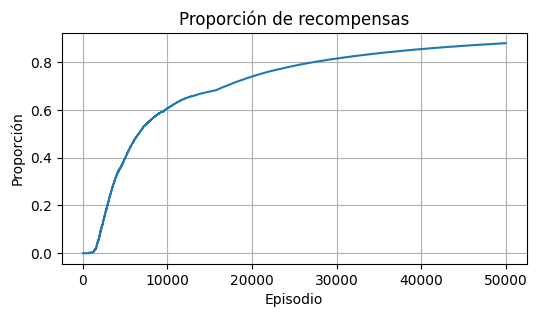

C:\Users\David\AppData\Local\Temp\ipykernel_50992\2428731217.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Máxima proporcion: 0.87916


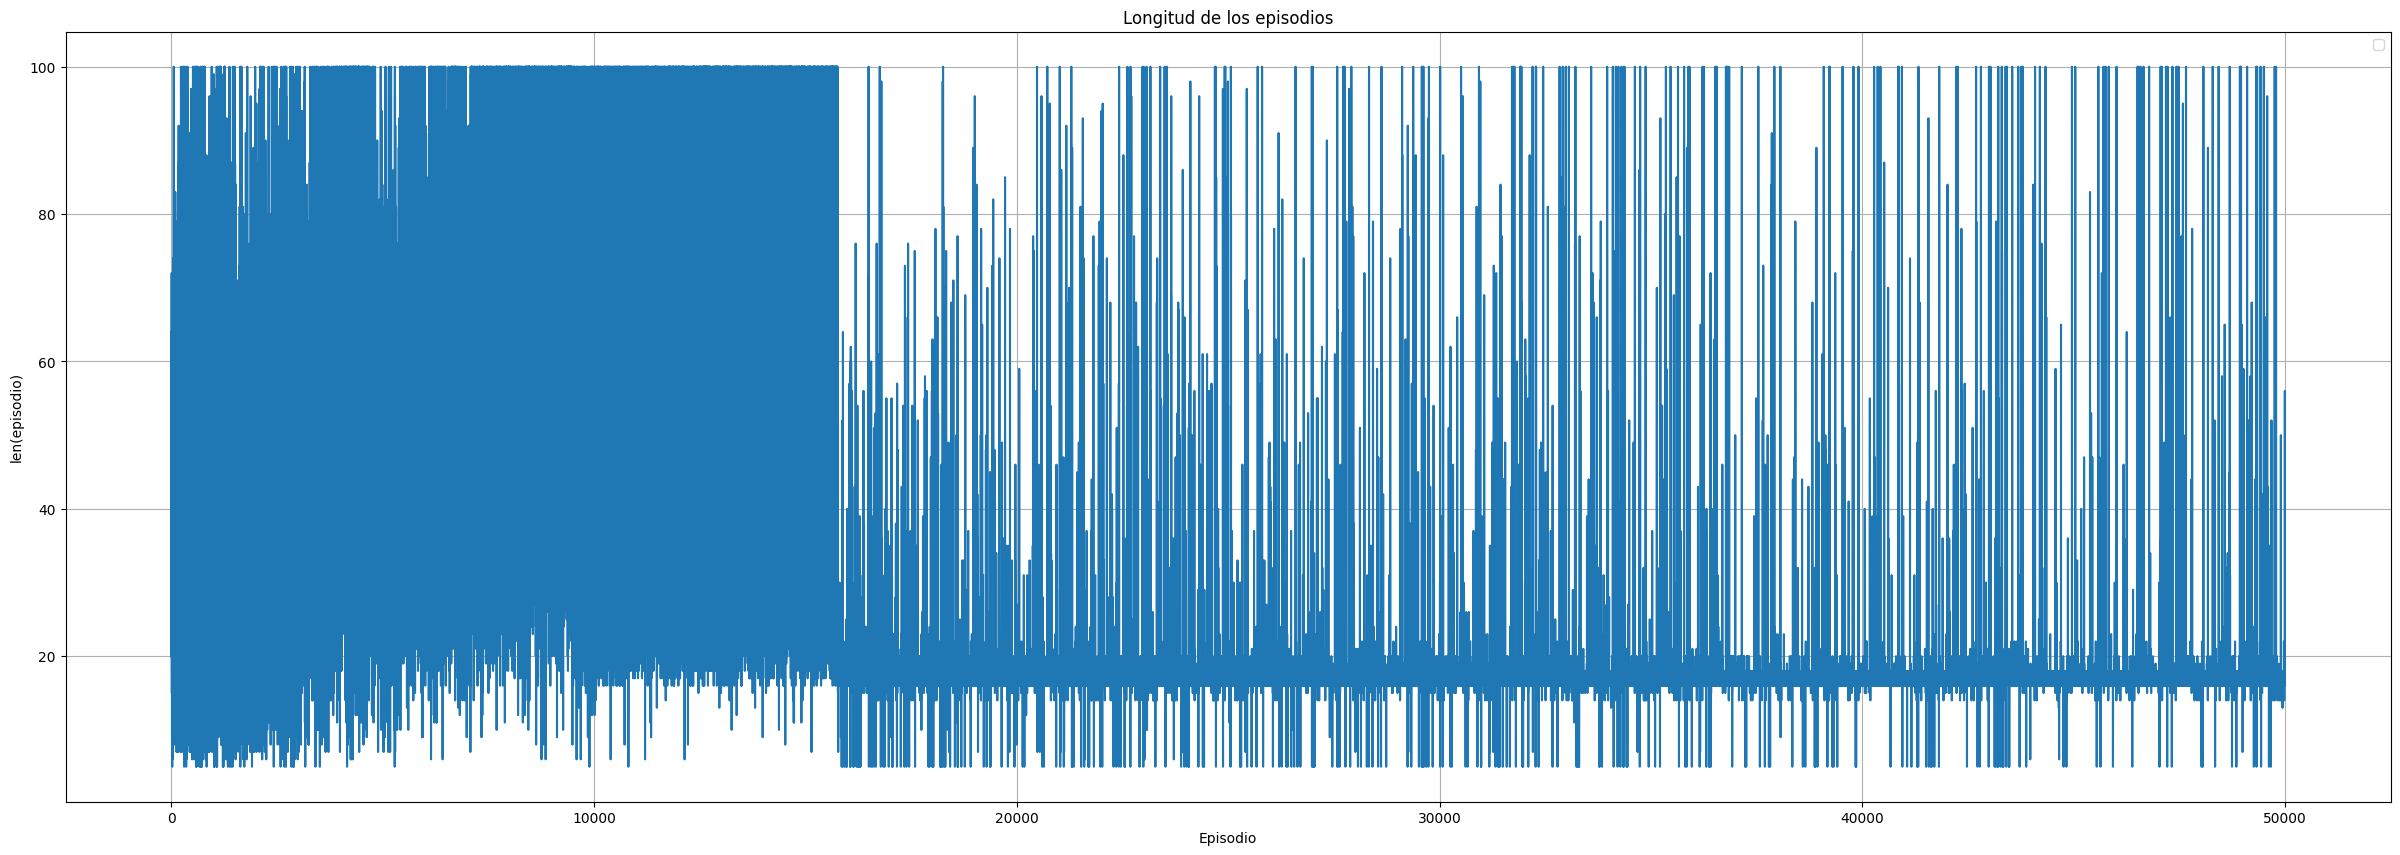

In [93]:
#@title Proporción de aciertos por número de episodios

plot(list_stats)
print(f"Máxima proporcion: {list_stats[-1]}")

plot_episode_length(episode_lengths)

#### Mostramos los valores Q para cada estado. Cada estado tienen 4 valores, que se corresponden con las 4 acciones que se pueden en cada estado.

In [94]:
# @title Tabla de valores Q
LEFT, DOWN, RIGHT, UP = 0,1,2,3
print("Valores Q para cada estado:\n", Q)

Valores Q para cada estado:
 [[0.643436   0.8936563  0.57502769 0.5428293 ]
 [0.43794286 0.54067096 0.5955613  0.61830623]
 [0.21328671 0.22591944 0.65257402 0.25      ]
 [0.51723202 0.49407328 0.93018258 0.55528855]
 [0.60411523 0.93207287 0.60655738 0.64676198]
 [0.62183544 0.65258964 0.68544601 0.69012555]
 [0.35416667 0.35891089 0.81270903 0.45597484]
 [0.40123457 0.84105385 0.45804196 0.40909091]
 [0.32090395 0.31964484 0.90613332 0.3020362 ]
 [0.3760917  0.37492643 0.90267817 0.33333333]
 [0.48239896 0.42689295 0.90657274 0.49589603]
 [0.53255304 0.         0.59326788 0.91497889]
 [0.60130719 0.61783439 0.93311494 0.64848993]
 [0.71458161 0.74193548 0.88233362 0.68816292]
 [0.77264573 0.80368098 0.96666667 0.79100281]
 [0.71723301 0.96199312 0.76621787 0.76005025]
 [0.03537415 0.04559271 0.40088106 0.0631136 ]
 [0.08471761 0.06621392 0.08761329 0.54327375]
 [0.06217617 0.07102273 0.         0.50494297]
 [0.         0.         0.         0.        ]
 [0.         0.26388889 0.73916

- También se muestra la política óptima (greedy) obtenida a partir del aprendizaje anterior.

- Cada estado tienen 4 valores, pero todos son 0 menos 1. Es decir, en cada estado se aplica de manera determinística una única acción.

*TODO:* Mostrar de forma gráfica el escenario.

In [95]:
# @title Política final
LEFT, DOWN, RIGHT, UP = 0,1,2,3
pi, actions = pi_star_from_Q(env8, Q)

print("Política óptima obtenida\n", pi, f"\n Acciones {actions} \n Para el siguiente grid\n", env8.render())
print()

Política óptima obtenida
 [[0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 0. 3.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] 
 Acciones 1,

## **4. Análisis y Estudios Futuros**

### **4.1 Análisis de Resultados**

- En los dos entornos (4x4 y 8x8), el agente comienza con un conocimiento muy limitado, pero gradualmente mejora su desempeño a medida que avanza en los episodios. Este comportamiento se puede observar en el gráfico de la proporción de recompensas, que aumenta con el tiempo.
- En el entorno 4x4, la máxima proporción de éxito alcanzada fue 0.522, mientras que en el entorno 8x8, la máxima alcanzada fue 0.914. Esto refleja que el agente aprendió a optimizar su estrategia en un entorno más complejo.
- La política óptima obtenida muestra las acciones recomendadas por el agente en cada estado del entorno. En el entorno 8x8, la política es más compleja debido a la mayor cantidad de estados y la dificultad del entorno.

### **4.2 Propuestas para Estudios Futuros**

1. **Evaluar con Otros Entornos**: Sería interesante aplicar este algoritmo a otros entornos más complejos de `gym`, como "Taxi-v3" o "MountainCar", para analizar cómo se comporta el agente en situaciones con dinámicas más complicadas.
   
2. **Optimización del Decaimiento de Epsilon**: Aunque se utilizó un decaimiento de epsilon en el segundo experimento, se podría investigar la efectividad de diferentes tasas de decaimiento o incluso explorar algoritmos como `Q-learning` para comparar su desempeño. Graficamente se trataría de mostrar la curva de la tasa de aciertos para distintas funciones de decaimientos

3. **Análisis del Impacto de los descuentos en las Recompensas**: El estudio se ha hecho para $\gamma = 1$; pero no se ha probado qué pasa cuando  $0 \leq \gamma < 1$. Se trataría de estudiar la curva para distintos valores de $\gamma$

4. **Nuevas gráficas**: Aquí solo se ha usado la proporción de aciertos, pero sería interesante qué relación entre dicha tasa y las tamaños de los episodios.

4. **Ampliación del Algoritmo**: Explorar otros enfoques de Monte Carlo o incluso combinar Monte Carlo con otros algoritmos de aprendizaje por refuerzo, como el Deep Q-Network (DQN), podría mejorar aún más los resultados en entornos más complejos.


In [96]:
class Agent:
    def __init__(self, env: gym.Env, epsilon: float = 0.4, decay: bool = False, discount_factor: float = 1.0):
        self.env = env
        self.nA = env.action_space.n
        
        # Hiperparámetros
        self.epsilon = epsilon
        self.decay = decay
        self.discount_factor = discount_factor
        
        # Tablas de aprendizaje
        self.Q = np.zeros([env.observation_space.n, self.nA])
        self.n_visits = np.zeros([env.observation_space.n, self.nA])
        
        # Memoria del episodio, almacenará tuplas (estado, acción, recompensa)
        self.episode = [] 
        
        # Variables para estadísticas
        self.stats = 0.0
        self.list_stats = [self.stats]
        self.episode_lengths = []
        self.step_count = 0
        self.t = 0

    def get_action(self, state):
        """
        Política epsilon-greedy. Se usa para el entrenamiento.
        """
        # Inicializamos las probabilidades base para todas las acciones
        pi_A = np.ones(self.nA, dtype=float) * self.epsilon / self.nA
        
        # Buscamos la mejor acción actual
        best_action = np.argmax(self.Q[state])
        
        # Le sumamos a la mejor acción la probabilidad restante
        pi_A[best_action] += (1.0 - self.epsilon)
        
        # Elegimos la acción basándonos en la distribución de probabilidades
        return np.random.choice(np.arange(self.nA), p=pi_A)

    def get_greedy_action(self, state):
        """
        Indicará qué acción realizar de acuerdo al estado durante la EVALUACIÓN.
        Responde a la política greedy.
        """
        # Seleccionamos directamente la acción con el mayor valor Q para ese estado
        action = np.argmax(self.Q[state])
        return action
    
    def update(self, obs, action, next_obs, reward, terminated, truncated, info):
        """
        Con la muestra (s, a, s', r) e información complementaria aplicamos el algoritmo.
        """
        # Sumamos el paso actual
        self.step_count += 1
        
        self.episode.append((obs, action, reward))
        
        done = terminated or truncated
        
        # Solo cuando el episodio termina, hacemos la actualización hacia atrás
        if done:
            # Guardamos la longitud del episodio para mostrar la evolución
            self.episode_lengths.append(self.step_count)
            
            # Actualizamos Q para ajustarnos a ese retorno
            G = 0.0
            for (state, act, rew) in reversed(self.episode):
                G = rew + self.discount_factor * G
                self.n_visits[state, act] += 1.0
                alpha = 1.0 / self.n_visits[state, act]
                
                # POR ESTO Q[state, action] es onpolicy
                self.Q[state, act] += alpha * (G - self.Q[state, act])
                
            # Guardamos datos sobre la evolución. Promedio de recompensas
            self.stats += G
            self.list_stats.append(self.stats / (self.t + 1))
            
            # Decaimiento del epsilon (preparándolo para el siguiente episodio)
            if self.decay:
                self.epsilon = min(1.0, 1000.0 / (self.t + 1))
                
            # Incrementamos el contador de episodios
            self.t += 1
            
            # Reiniciamos las variables locales del episodio para el siguiente
            self.episode = []
            self.step_count = 0
    
    def get_stats(self):
        """Retorna los resultados estadísticos, evolución y la matriz Q"""
        return self.Q, self.list_stats, self.episode_lengths

In [ ]:
n_episodes = 50000

# 2. Instanciamos nuestro agente de Monte Carlo
agent = Agent(env4, epsilon=0.4, decay=False, discount_factor=1.0) 

step_display = n_episodes / 10

# 3. Bucle de entrenamiento
for episode in tqdm(range(n_episodes)):
    state, info = env4.reset(seed=seed)
    done = False
    
    # Jugamos un episodio completo
    while not done:
        # El agente decide la acción según su política (epsilon-greedy)
        action = agent.get_action(state)
        
        # El entorno reacciona y nos da el siguiente estado y recompensa
        next_state, reward, terminated, truncated, info = env4.step(action)
        
        # Actualizamos el agente (sin poner 'self' en los argumentos de llamada)
        agent.update(state, action, next_state, reward, terminated, truncated, info)
        
        # Comprobamos si el episodio ha terminado y avanzamos el estado
        done = terminated or truncated
        state = next_state
        
    # Mostramos la evolución en el terminal, calcando tu código original
    if episode % step_display == 0 and episode != 0:
        print(f"success: {agent.stats / episode}, epsilon: {agent.epsilon}")

# 4. Obtenemos los resultados estadísticos finales
Q, list_stats, episode_lengths = agent.get_stats()

 11%|█         | 5601/50000 [00:02<00:11, 3743.80it/s]

success: 0.3124, epsilon: 0.4


 21%|██        | 10543/50000 [00:04<00:10, 3754.37it/s]

success: 0.4162, epsilon: 0.4


 31%|███       | 15438/50000 [00:05<00:09, 3639.05it/s]

...

 81%|████████  | 40599/50000 [00:12<00:02, 3505.05it/s]

success: 0.508875, epsilon: 0.4


 91%|█████████ | 45407/50000 [00:13<00:01, 3766.36it/s]

success: 0.5143777777777778, epsilon: 0.4


100%|██████████| 50000/50000 [00:14<00:00, 3391.00it/s]


#### Mostramos los valores Q para cada estado. Cada estado tienen 4 valores, que se corresponden con las 4 acciones que se pueden en cada estado.

In [100]:
# @title Tabla de valores Q
LEFT, DOWN, RIGHT, UP = 0,1,2,3
print("Valores Q para cada estado:\n", Q)


Valores Q para cada estado:
 [[0.14581601 0.51316832 0.38344043 0.39425807]
 [0.15811285 0.         0.57138305 0.39409283]
 [0.3887423  0.61722405 0.50673195 0.54607509]
 [0.59568345 0.         0.33333333 0.44604317]
 [0.23971664 0.60367137 0.         0.46217753]
 [0.         0.         0.         0.        ]
 [0.         0.81370728 0.         0.55437666]
 [0.         0.         0.         0.        ]
 [0.36906441 0.         0.70912409 0.50135501]
 [0.56977798 0.82691952 0.795732   0.        ]
 [0.69938335 0.96004709 0.         0.62919634]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.83404711 0.95855792 0.72167488]
 [0.82442748 0.96278108 1.         0.80707917]
 [0.         0.         0.         0.        ]]


In [ ]:
# @title Política final
LEFT, DOWN, RIGHT, UP = 0,1,2,3
agent.get_greedy_action()

print("Política óptima obtenida\n", pi, f"\n Acciones {actions} \n Para el siguiente grid\n", env4.render())
print()